In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
data = pd.read_csv('../M1_final.csv')
data.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,32,58,W,24,35,29.91,Fair / Windy,9,17,13


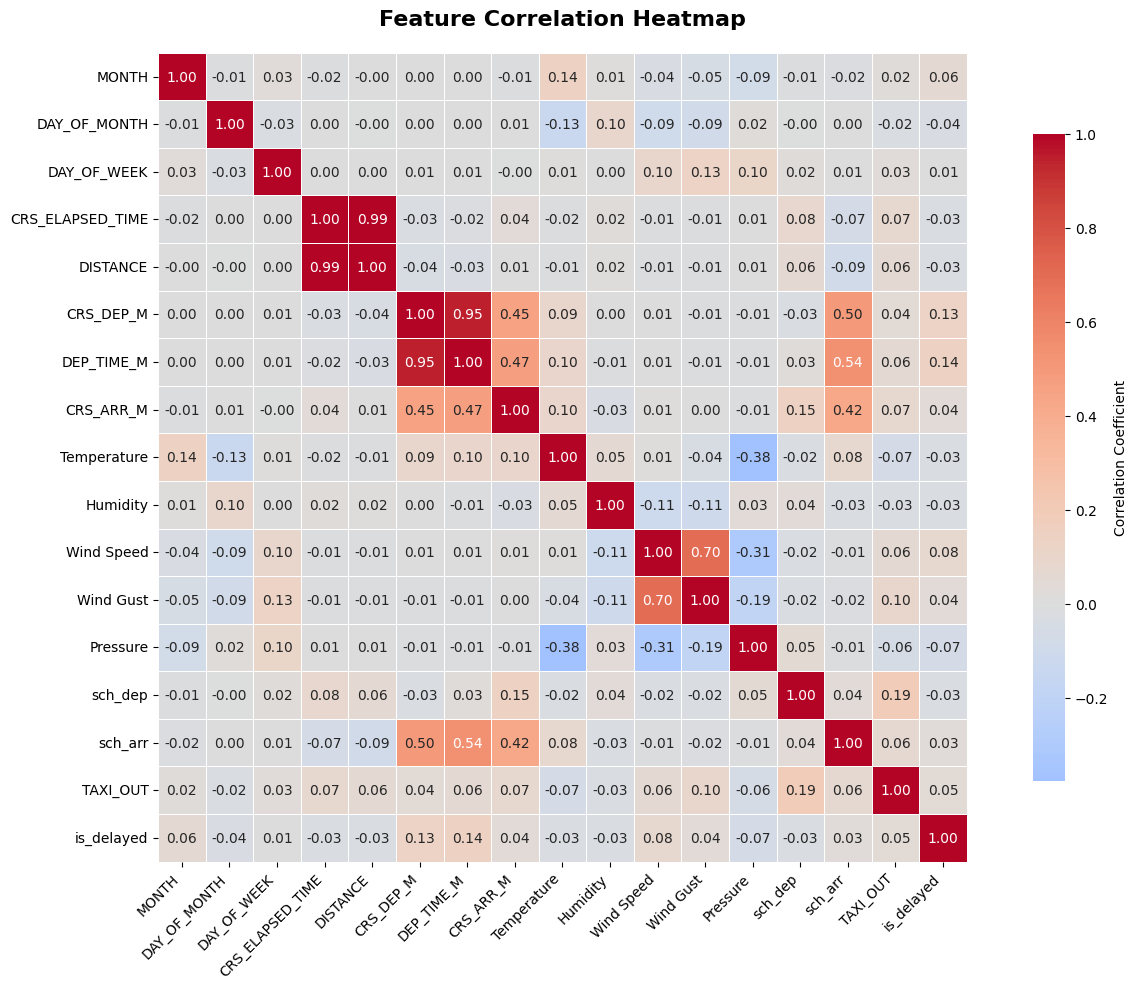

In [9]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

In [10]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

In [11]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

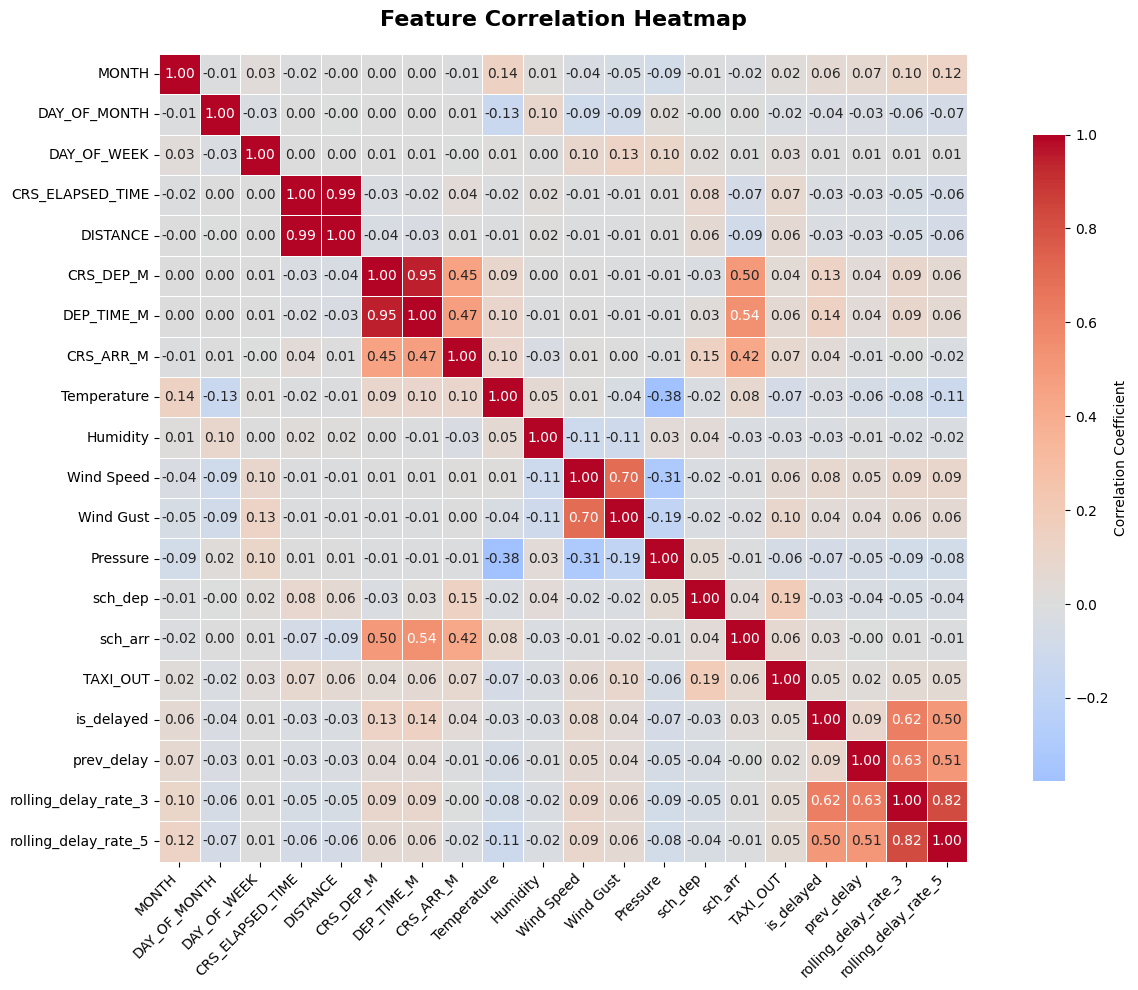

In [13]:
import seaborn as sns

# Calculate correlation matrix
data = create_temporal_features(data)

corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)

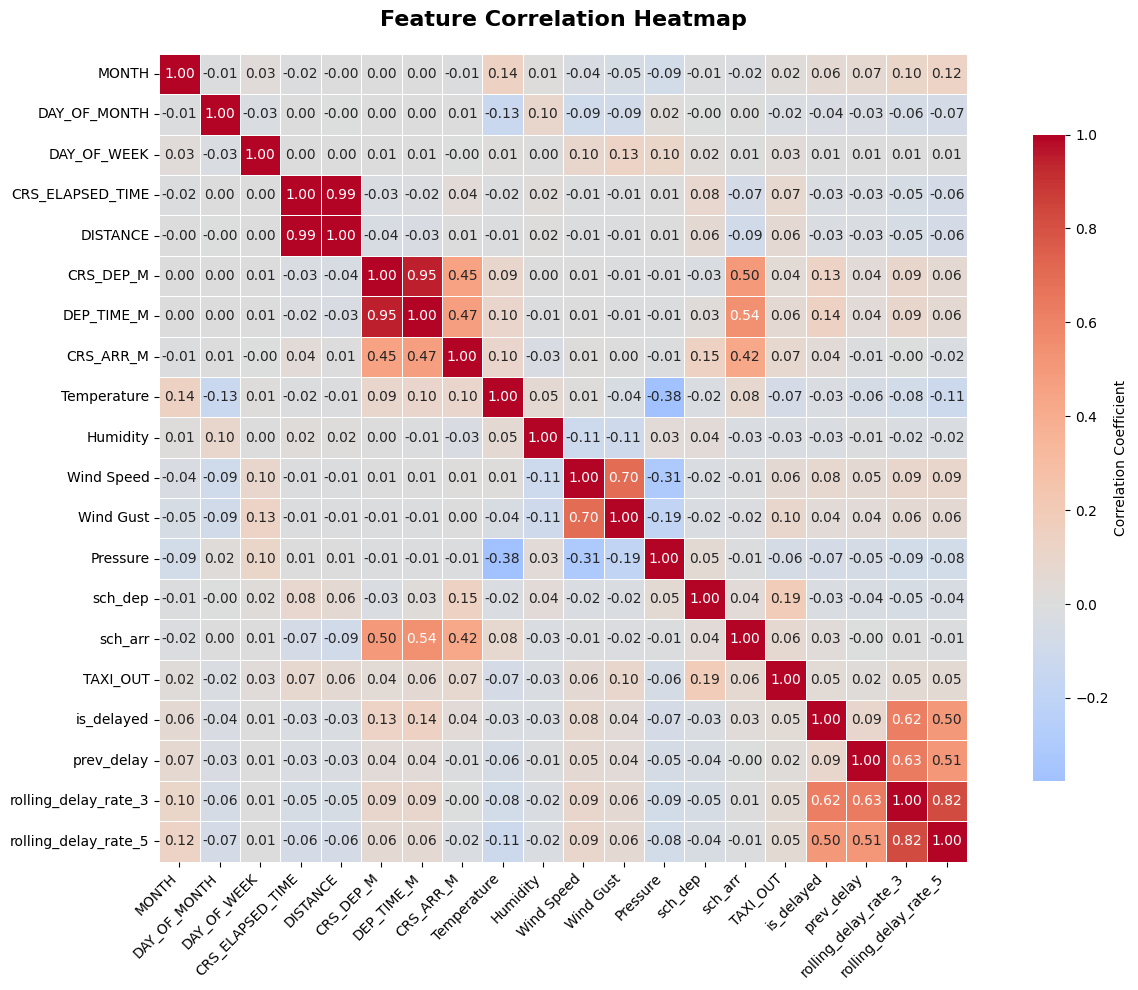

In [15]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Create enhanced heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (blue for negative, red for positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square-shaped
    linewidths=0.5,       # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analyzing Time of Day vs Delay Correlation

We'll explore the relationship between time_of_day and is_delayed using multiple methods:

In [17]:
# Method 1: Crosstab to see delay rates by time of day
delay_by_time = pd.crosstab(
    data['time_of_day'], 
    data['is_delayed'], 
    normalize='index'
) * 100

print("Delay Rate (%) by Time of Day:")
print(delay_by_time)
print("\n" + "="*50 + "\n")

# Calculate actual delay rate for each time period
delay_rate = data.groupby('time_of_day')['is_delayed'].agg(['mean', 'count'])
delay_rate['delay_rate_%'] = delay_rate['mean'] * 100
delay_rate = delay_rate.sort_values('delay_rate_%', ascending=False)

print("Detailed Delay Statistics by Time of Day:")
print(delay_rate)

Delay Rate (%) by Time of Day:
is_delayed           0          1
time_of_day                      
Afternoon    84.586050  15.413950
Evening      81.271424  18.728576
Morning      90.926036   9.073964
Night        79.959514  20.040486


Detailed Delay Statistics by Time of Day:
                 mean  count  delay_rate_%
time_of_day                               
Night        0.200405   2470     20.040486
Evening      0.187286   6418     18.728576
Afternoon    0.154140   8129     15.413950
Morning      0.090740  11803      9.073964


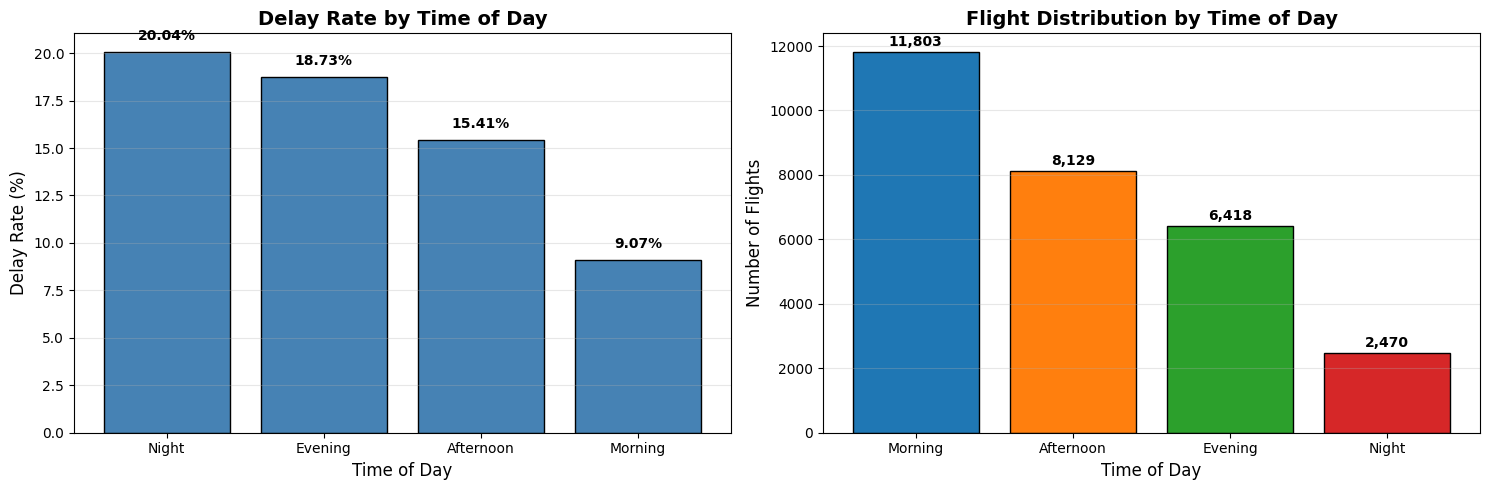

In [18]:
# Method 2: Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of delay rates
delay_rate_plot = data.groupby('time_of_day')['is_delayed'].mean() * 100
delay_rate_plot = delay_rate_plot.sort_values(ascending=False)

axes[0].bar(delay_rate_plot.index, delay_rate_plot.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Time of Day', fontsize=12)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Delay Rate by Time of Day', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, val) in enumerate(delay_rate_plot.items()):
    axes[0].text(i, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Count plot
time_counts = data['time_of_day'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].bar(time_counts.index, time_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].set_ylabel('Number of Flights', fontsize=12)
axes[1].set_title('Flight Distribution by Time of Day', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, val) in enumerate(time_counts.items()):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28820 entries, 19202 to 18941
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MONTH                 28820 non-null  int64  
 1   DAY_OF_MONTH          28820 non-null  int64  
 2   DAY_OF_WEEK           28820 non-null  int64  
 3   OP_UNIQUE_CARRIER     28820 non-null  object 
 4   TAIL_NUM              28820 non-null  object 
 5   DEST                  28820 non-null  object 
 6   CRS_ELAPSED_TIME      28820 non-null  int64  
 7   DISTANCE              28820 non-null  int64  
 8   CRS_DEP_M             28820 non-null  int64  
 9   DEP_TIME_M            28820 non-null  int64  
 10  CRS_ARR_M             28820 non-null  int64  
 11  Temperature           28820 non-null  int64  
 12  Dew Point             28820 non-null  object 
 13  Humidity              28820 non-null  int64  
 14  Wind                  28818 non-null  object 
 15  Wind Speed          

In [19]:
data['Condition'].unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Light Rain', 'Cloudy', 'Fair',
       'Cloudy / Windy', 'Fair / Windy', 'Light Snow', 'Rain',
       'Mostly Cloudy / Windy', 'Wintry Mix', 'Light Drizzle', 'Fog',
       'Partly Cloudy / Windy', 'Fog / Windy', 'Light Rain / Windy',
       'Rain / Windy', 'Wintry Mix / Windy', 'Heavy Rain',
       'Light Snow / Windy', 'Heavy Rain / Windy', 'Drizzle and Fog',
       'Light Drizzle / Windy', 'Light Freezing Rain', 'Snow'],
      dtype=object)